<a href="https://colab.research.google.com/github/Chau-Nguyen-Developer/Google-Intro-Computer-Vision-Model-TensorFlow/blob/main/Chau_Google_ComputerVision_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---Instruction Website - Build a Computer Vision Model with TensorFlow: https://developers.google.com/codelabs/tensorflow-2-computervision#0




In [1]:
import tensorflow as tf
print(tf.__version__)

2.19.0


**Load The Fashion MNIST Dataset**

In [2]:
mnist = tf.keras.datasets.fashion_mnist

**Separate dataset into two lists: training values and testing values**

In [3]:
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


^^ The line above is loading a pre-split dataset from Keras (MNIST).   
`mnist.load_data()` already returns two splits:
1. Training set -> `(training_images, training_labels)`
2. Test set -> `(test_images, test_labels)`

# Why we would need two datasets--training and testing?  
The idea is to have one set of data for training and another set of data that the model has not _yet_ encountered to see how well it can classify values. After all, at the end, we want to use the model with data that it _had not previously seen!_  

Also, without separate testing data, you will run the risk of the network ONLY MEMORIZING its training data (we don't want this) without GENERALIZING its knowledge (we want this).

^^ explaining for the above: the big set is divided into two smaller sets. Each set is further divided into images and their corresponding labels:

`training_images`: Contains the images used to train the machine learning model.
`training_labels`: Contains the labels (e.g., categories like 't-shirt', 'trouser') for the training_images.  

`test_images`: Contains images used to evaluate the model's performance after it has been trained.  
`test_labels`: Contains the labels for the test_images.

**Try to see what those value looks like.**   
Print out a training image and a training label to see.

Printing out training image at index 0.
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   

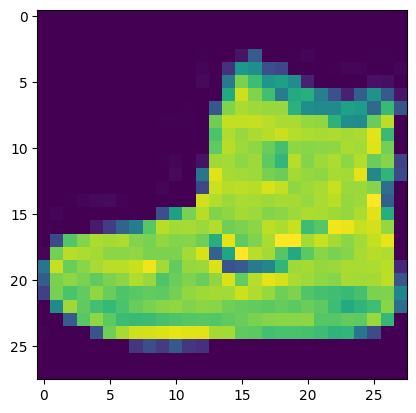

In [4]:
import matplotlib.pyplot as plt
plt.imshow(training_images[0])
print("Printing out training image at index 0.")
print(training_images[0])
print("\nPrinting out training labels at index 0")
print(training_labels[0])

**Try to see a different image**

8
[[  0   0   0   0   0   0   0   0   0   1   0   0  18 107 119 103   9   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  99 155 113  61 118 173 117
    0   0   3   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   1   0 110 136   0   0   0   0   0 167
  159   0   0   2   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0   6   0  72 147   0   0   5   0   2   0   0
  174 118   0   5   0   0   0   0   0   0]
 [  0   0   0   0   0   1   5   0   0 174   4   0   4   0   0   0   0   0
    0 204  44   0   4   0   0   0   0   0]
 [  0   0   0   0   0   0   8   0 125 128   0   9   0   0   0   0   0   2
    0 107 152   0   6   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 184   9   0   4   0   0   0   0   0   2
    0   0 190   0   0   2   0   0   0   0]
 [  0   0   0   1   0   2   0  73 158   0   0   0   0   1   0   0   0   0
    4   0 157  79   0   3   1   0   0   0]
 [  0   0   2   5   1   0   0 157  98   0   2   0   0   1   0 

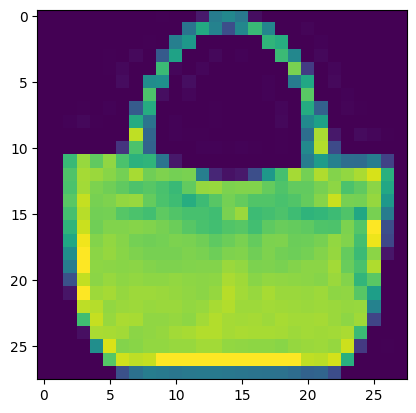

In [5]:
# Display an image
plt.imshow(training_images[100])
#Print image label at index 100
print(training_labels[100])
#Print image data at index 100
print(training_images[100])

2
[[  0   0   0   0   1   0   0   0   0  22  88 188 172 132 125 141 199 143
    9   0   0   0   1   0   0   0   0   0]
 [  0   0   0   1   0   0  20 131 199 206 196 202 242 255 255 250 222 197
  206 188 126  17   0   0   0   0   0   0]
 [  0   0   0   1   0  35 214 191 183 178 175 168 150 162 159 152 158 179
  183 189 195 185  82   0   0   0   0   0]
 [  0   0   0   0   0 170 190 172 177 176 171 169 162 155 148 154 169 174
  175 175 177 183 188  12   0   0   0   0]
 [  0   0   0   0  25 194 180 178 174 184 187 189 187 184 181 189 200 197
  193 190 178 175 194  90   0   0   0   0]
 [  0   0   0   0  42 218 191 197 208 204 211 209 210 212 211 214 215 213
  214 211 211 191 200 158   0   0   0   0]
 [  0   0   0   0  88 221 215 217 219 211 185 150 118 107  99  88  83  90
  135 212 203 207 219 169   0   0   0   0]
 [  0   0   0   0   0  27 118 162  40   0   0   0  10  19  28  39  47  36
    0   0 203 230 220 203   0   0   0   0]
 [  0   0   0   0 138 136  71  69  54 216 217 203 184 168 163 

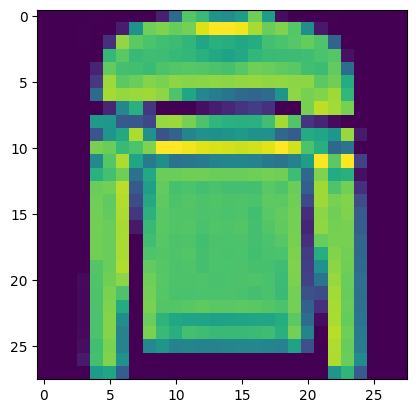

In [6]:
# Display an image
plt.imshow(training_images[5])
#Print image label at index 5
print(training_labels[5])
#Print image data at index 5
print(training_images[5])

7
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   3   0   0   0   0   0  87  59   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 

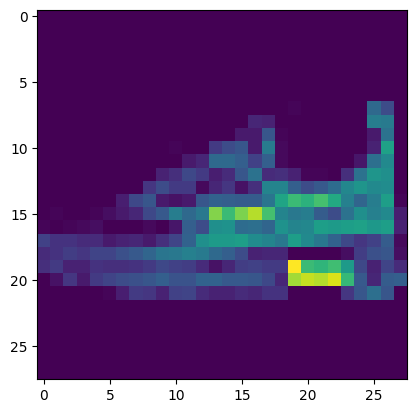

In [7]:
# Display an image
plt.imshow(training_images[2001])
#Print image label at index 2001
print(training_labels[2001])
#Print image data at index 2001
print(training_images[2001])

### Normalization. Turn all values to between 0 and 1.

In [8]:
training_images = training_images / 255.0
test_images = test_images/255.0

9
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.00392157 0.  

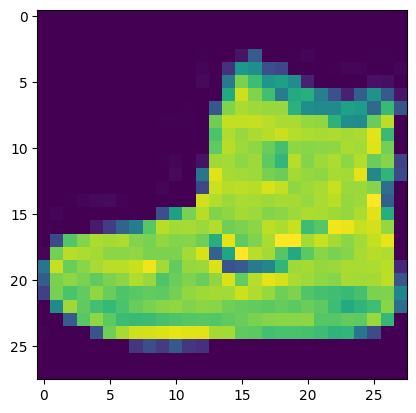

In [9]:
### Look at the boot at image [0]
plt.imshow(training_images[0])
print(training_labels[0])
print(training_images[0])

9
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.  

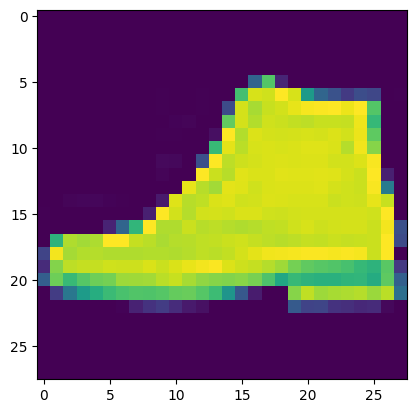

In [10]:
plt.imshow(training_images[42])
print(training_labels[42])
print(training_images[42])

# DESIGN THE MODEL

In [11]:
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])

### Explanation
1. `Sequential` = defines a sequence of layers in the neural network
2. `Flatten` = takes a square and turns it into a 1D vector
3. `activation` functions tell each layer of neurons what to do. There are a lot of options, and we are using these for now:
4. `ReLU`= rectified linear unit. It means that if X is greater than 0, then return X. Otherwise, return 0. It will omit negative values and only passes values of 0 or greater to the next layer in the network. `ReLU(x) = max(0,x)`. Negative values will turn to 0, and positive values stay the same.
5. `softmax` = takes a set of values, and effectively picks the biggest one. For example, if the output of the last layer looks like [0.1, 0.1, 0.05, 0.1, 9.5, 0.1, 0.05, 0.05, 0.05], then it saves you from having to sort for the largest value—it returns [0,0,0,0,1,0,0,0,0]


^^ More explanation for the above:
* `Flatten()` takes a multi-dimenstional tensor and reshapes it into a 1D vector per sample. `(28,28) -> (784,0)`. We do this because the `Dense layers` expect input like this `[feature1, feature2, feature3, ...]`. Flatten function helps us conver the image into that format and prepares the image while `Dense` layers do the learning.
* Flatten does not learn anything. It just reshapes data.

* `tf.keras.layers.Dense(128, activation='relu')`. This does not mean take 128 inputs. It means create 128 neurons, and each connected to all 784 inputs.
* Internally, each neuron computes
`output = activation(weight1 * x1 + weight2 * x2 + ... + weight784 * x784 + bias)`. We have 128 of these neurons.
* 784 = number of input features (fixed by the image)
* 128 = number of neurons (our design choice). 128 is a good choice and a good balance because it can learn meaningful patterns (edges, shapes, strokes) and not too big (avoids overfitting and keep computation reasonable).


### More about those functions.
* These functions help us add non-linearity into our model. `ReLU` lets the model learn edges, shapes, and patterns.
* Older activatons like sigmoid/tanh can make learning very slow in deep networks. ReLU helps gradients flow better.
* When training a neural network, we update weights using gradients (via back propagation). If gradients become very small, earlier layers basically stop learning. Gradient is vanishing.

### More about sigmoid function
https://www.geeksforgeeks.org/machine-learning/derivative-of-the-sigmoid-function/

#### Sigmoid
* With Sigmoid, backprop uses the chain rule. If each derivative is small (like 0.01), then: 0.01 x 0.01 x 0.01 x ... --> almost zero. So, early layers get almost no signal, and they do not learn. With gradients, when x > 0, derivative = 1. Instead of shrinking, 1 x 1 x 1 x 1 x ... = 1 (no shrinking). We can think of gradients like a signal traveling backward. With sigmoid, signal fades away. With ReLU, signal passes through clearly.

* Sigmoid --> squashes everything into a tiny range [0,1] --> gradients shrink

* ReLU --> keeps positive values unchanged --> gradients survive

#### Trade off of ReLU
If input is always <= 0:  
* output = 0
* gradient = 0
* neuron stops learning



### Softmax

Softmax converts raw ouputs into probabilities. Softmax takes a list of raw scores and turns them into probabilities that add up to 1.

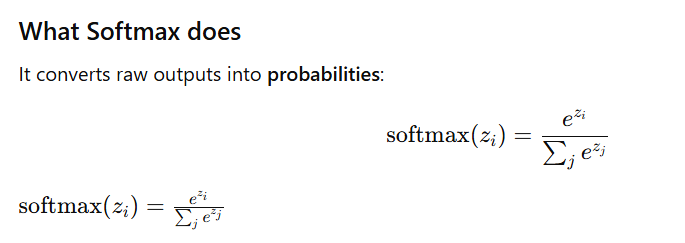

Softmax function amplifies the largest values and supprsses smaller ones, then _normalizes_ everything so the outputs can be interpreted as probabilities.

There are ten labels for clothings items, so we have ten neurons.

Each neuron looks at the 128 features from the previous layer and computes a score like this:
`score = w1 * f1 + w2 * f2 + w3 * f3 + ... + w128 * f128 + bias`. So each neuron learns what each cloth items (labels) look like (hat, scarf, shoes, shirt, etc).   

The neurons are structually the same, but they have different weights.

Each output neuron is a "detector" for one class, and **softmax turns their scores into probabilities.**

# Compile and train the model

We just finished defining the architecture of the model. Now, we build it by first compiling it with an `optimizer` and `loss` function, then train it on our training data and labels.

Our goal is to have the model `figure out the relationship between the training data and its training labels.`

Later, we want our model to see data that resembles our training data, and then make a prediction about what that data should look like.

In [12]:
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = "sparse_categorical_crossentropy",
              metrics = ["accuracy"])

### Optimizer (this controls how weights get updated)

##### Adam:
* Uses gradients (from backpropagation)
* Automatically adapts learning speed
* Works well in most cases (default choice)

Review SGD (Stochastic Gradient Descent). Concept: `new_weight = old_weight - learning_rate x gradient`. Characteristics: it uses a **fixed learning rate**, same step size for all parameters. It is simple and predictable.

##### Compare SGD with Adam (Adaptive Moment Estimation)  

Adam is smarter than SGD. It keeps track of momentum (past gradients), and it adapts learning rates per parameters. `Instead of one learning rate, each weight gets its own adjusted learning rate.` It adjusts step size automcatically based on past behavior.

Charatersitisc of Adam: faster convergence, less tuning needed, and handle noisy data well. Cons: sometimes less generalization than SGD.



### Loss Function
`loss = "sparse_categorical_crossentropy"`
* sparse = expects integer labels
* Not this: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
* "Integer labels" store just the class number, while "one-hot vectors" store a full vector with a 1 at the correct class.

### Metrics
`metrics = ['accuracy']`

Accuracy = correct predictions / totoal predictions.

Accuracy measures how many we get right. This metric works well for `balanced datasets`.

For `imbalanced datasets`, accuracy can be misleading in some cases.  

Review popular metrics:  
* `Accuracy`: How many predictions were correct overall? Out of everything, how often am I right?
`accuracy = (TP+TN)/(TP + TN + FP + FN)`

* `Precision`: When I say it is "spam email", how often am I correct? Can I trust my positive predictions?
`precision = TP / (TP + FP)`

* `Recall`: Out of all real spam emails, how many did I catch? Did I miss important cases?  
`recall = TP / (TP + FN)`

```
accuracy --> overall correctness  
precision --> when I predict "yes", am I right? I care about false positives.
recall --> did I catch all the "yes" cases? I care about false negatives.
```

In [13]:
model.fit(training_images, training_labels, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8240 - loss: 0.4988
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8626 - loss: 0.3768
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8774 - loss: 0.3375
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8846 - loss: 0.3141
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8907 - loss: 0.2965
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8956 - loss: 0.2799
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9007 - loss: 0.2677
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9036 - loss: 0.2577
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9075 - loss: 0.2481
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9111 - loss: 0.2386


When the model is done training, we can see the accuracy value at the end of the final epoch. In the last run, accuracy is 0.8337, and the loss is 0.4977. This tells us that our neural network is about 83.37% accurate in classifying the training data. About loss, on average, the model's predictions are moderately wrong, with a cross-entropy error of about 0.5.

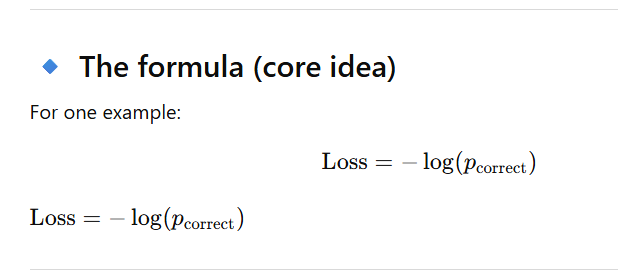




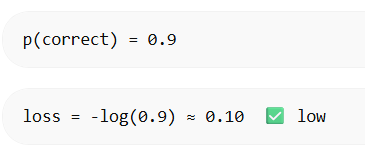

Log function encourages high confidence in the correct class and punishes confident mistakes harshly.


Snap shot of running `model.fit()` function on 04/03/2026.


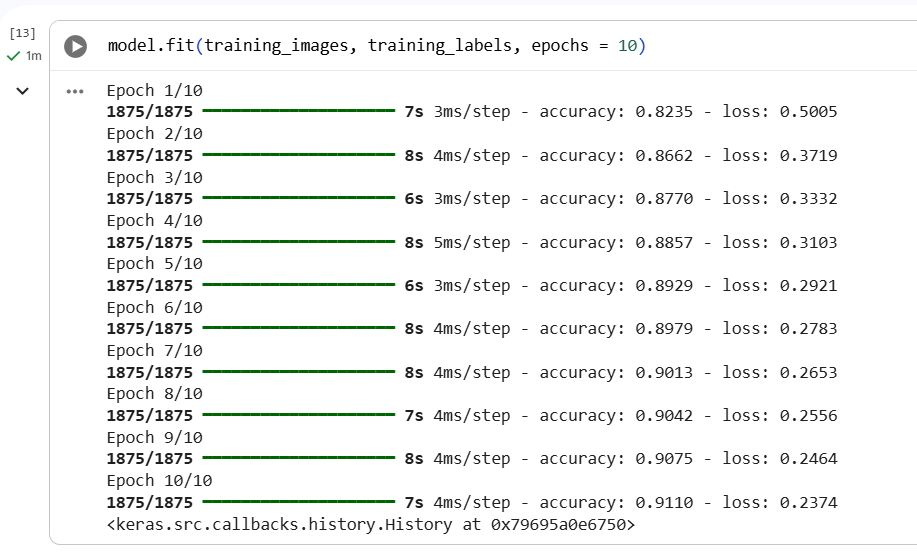

Observation: may experience "overfit". Accuracy is unusually hight. Up to 0.9110, with the loss 0.2374.


# TEST THE MODEL  
Evaluate the model on the data that it has not seen. Call the function `model.evaluate()` and pass in `test set`.

In [14]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8873 - loss: 0.3309


[0.33088573813438416, 0.8873000144958496]

(Below is the snap shot of how well the model behave on 04/03/2026.) The model returned an accuracy of 0.8858, meaning it was about 88.58% accurate (less than 91.10% with the data it was trained on.)

We will learn more about TensorFlow to improve that.

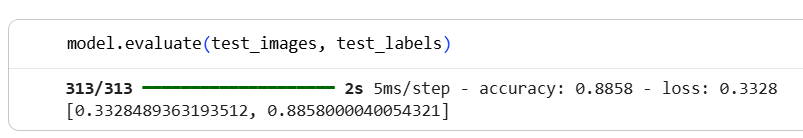

# EXPLORATION EXERCISE


#### Review
Label and Description:   

0. T-shirt/top
1. Trouser
2. Pullover
3. Dress
4. Coat
5. Sandal
6. Shirt
7. Sneaker
8. Bag
9. Ankle boot

### Exercise 1
`model.predict()` --> It creates a set of classifications for each of the test images.

In [15]:
classifications = model.predict(test_images)
print(classifications[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[3.2914129e-06 4.9842930e-07 5.4206280e-06 3.9047390e-07 8.7795570e-07
 9.0501737e-03 1.1834919e-05 1.1360504e-02 3.9069723e-06 9.7956324e-01]


In [16]:
print(classifications[100])

[9.6295821e-03 3.4169992e-05 3.7285246e-04 9.8404199e-01 1.8671091e-04
 6.8899695e-08 5.6626350e-03 1.2132552e-09 7.1063936e-05 8.8734828e-07]


In [17]:
print(classifications[330])

[5.8343649e-06 5.6424860e-06 2.5893354e-07 9.9997348e-01 6.3213157e-08
 1.6315125e-12 1.5954662e-06 5.7682984e-14 1.3080208e-05 1.7901290e-10]


In [18]:
print(classifications[9])

[2.3912849e-09 2.3498421e-09 1.9458297e-09 8.5367219e-10 4.2987992e-11
 1.2993154e-06 8.3537421e-10 9.9999779e-01 2.9487468e-08 8.6414246e-07]


**Question 1**: The above code creates a set of classifications for each of the test images. The output after you run it is a list of numbers. Why do you think that is and what do those numbers represent?

**My answer**: Those numbers represent on the probabilities of my picture match up with different kinds of clothing and boots items. When I ran the code and got the list, the value at index 9 has the highest probability number (9.9681240e-01), so we can conclude that the test_images[0] has the highest probability to be an ankle boot.

**A snapshot showing the probability distribution of possible item types for the element at index 0.**

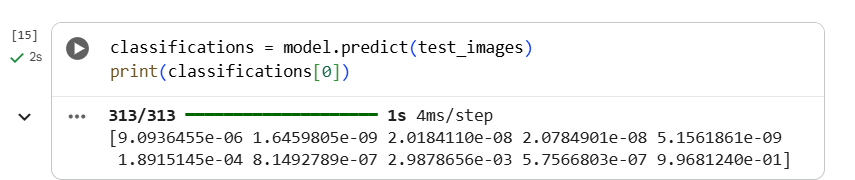

**Answer from the [blog](https://developers.google.com/codelabs/tensorflow-2-computervision#5)**  

The output of the model is a list of 10 numbers. Those numbers are a probability that the value being classified is the corresponding label. For example, the first value in the list is the probability that the clothing is of class 0 and the next is a 1. Notice that they are all very low probabilities except one. Also, because of Softmax, all the probabilities in the list sum to 1.0.  

The list and the labels are 0 based, so the ankle boot having label 9 means that it is the 10th of the 10 classes. **The list having the 10th element being _the highest value_ means that the neural network has predicted that the item it is classifying is most likely an ankle boot.**

**We print out test_labels to double check**

In [19]:
print(test_labels[0])

9


**Print out picture at test_images[0] to double check. We can visually verify that the image is indeed an ankle boot**.

9
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.  

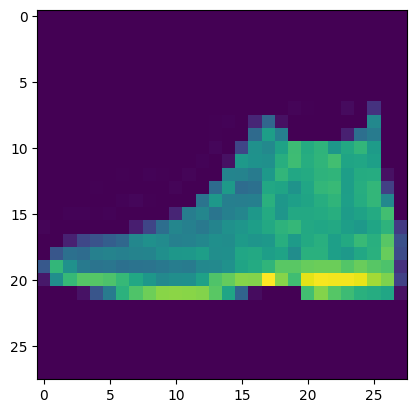

In [20]:
plt.imshow(test_images[0])
print(test_labels[0])
print(test_images[0])

### Exercise 2
Look at the layers in your model. Experiment with different values for the dense layer with 512 neurons. What different results do you get for loss and training time? Why do you think that is the case?  

In [21]:
#Design the model
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(512, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])

In [22]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [23]:
# Train the model
model.fit(training_images, training_labels, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8303 - loss: 0.4764
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8678 - loss: 0.3588
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8815 - loss: 0.3219
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8892 - loss: 0.2999
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8963 - loss: 0.2828
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8996 - loss: 0.2670
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9052 - loss: 0.2523
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9101 - loss: 0.2405
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9134 - loss: 0.2299
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9151 - loss: 0.2222


**My Observation:** with the dense layer changing from having 128 nodes (lenses) to having 512 nodes, the accuracy increases.

In [24]:
# Test the model
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8859 - loss: 0.3367


[0.33670923113822937, 0.8859000205993652]

Try out with 1024 neurons.

In [25]:
# Design the architecture
model2 = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
# Compile
model2.compile(optimizer="adam",
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])
# Training
model2.fit(training_images, training_labels, epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8304 - loss: 0.4711
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8676 - loss: 0.3569
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8817 - loss: 0.3192
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8901 - loss: 0.2963
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8963 - loss: 0.2793


Running on 04/03/2026 with 1024 neurons, the accuracy is 0.8972, and the loss is 0.2780.

Running on 04/04/2026 with 1024 neurons, with accuracy is 0.8963, and the loss is 0.2793.

When we increase to 1024 neurons, we have to do more calculations, slowing down the process. The good thing is that they will have a good impact because the model is more accurate. One thing to note, that does not mean more is always better. We can hit the law of diminishing returns very quickly.

### Exercise 3
What would happen if you remove the `Flatten()` layer? Why do you think that is the case?




In [26]:
model3 = tf.keras.models.Sequential([
  tf.keras.layers.Dense(512, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [29]:
# model3.compile(optimizer="adam", loss="sparse_categorical_crossentropy")
# model3.fit(training_images, training_labels, epochs=5)
# model3.evaluate(test_images, test_labels)


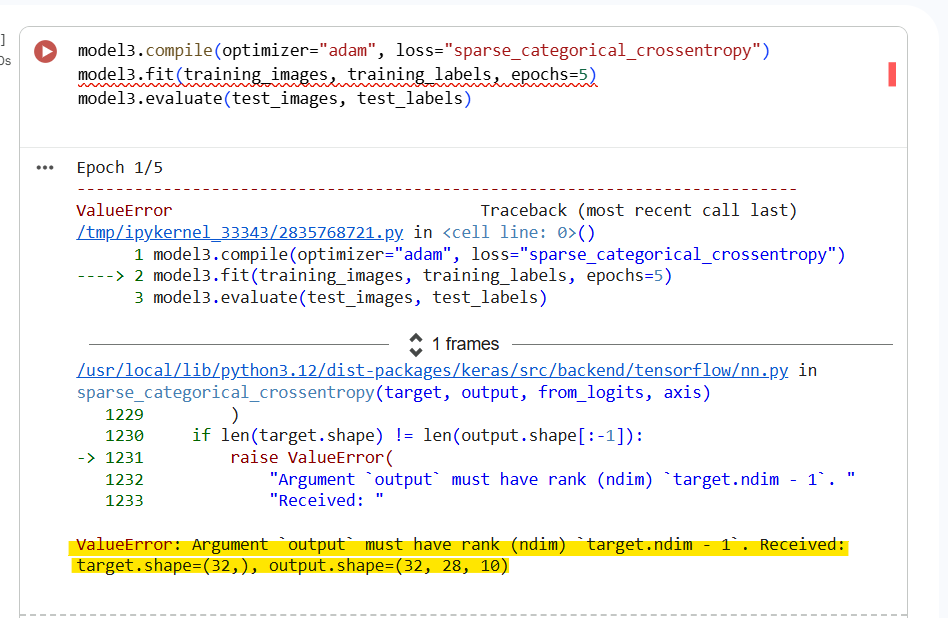

The above error happened because we did not flatten out the shape of data. Right now, data is 28 x 28 images, and 28 layers of 28 neurons would be infeasible, so it makes sense to flatten that 28x28 into a 784x1. The layer `Flatten()` at the beginning will automatically do the task for you.

### Exercies 4
Consider the final (output) layers. Why are there 10 of them? What would happen if you had a different amount than 10?


**My answer:**
Final (output)layers have 10 neurons as we have 10 labels (index from 0 to 9). Each neuron will tell me how likely my cloth items will be.

**My answer** (with the help of paraphrase from ChatGPT): The final output layer has 10 neuron, corresponding to the 10 possible labels (0 through 9). Each neuron represents the likelihood that the clothing item belongs to its respective category.

**From the blog**: A rule of thumb: the number of neurons in the last layer should _match the number of classes_ you are classifying for. In this case, it's the digits 0 through 9, so there are 10 of them, and hence, we should have 10 neurons in our final layer.

### Exercise 5
Consider the effects of additional layers in the network. What will happen if you add another layer between the one with 512 and the final layer with 10?

In [33]:

model4 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation=tf.nn.relu),
  tf.keras.layers.Dense(512, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
model4.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=["accuracy"])
model4.fit(training_images, training_labels, epochs=5)
model4.evaluate(test_images, test_labels)
classifications4 = model4.predict(test_images)
print(classifications4[0])
print(test_labels[0])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6689 - loss: 1.4875
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6849 - loss: 0.9041
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6940 - loss: 0.8275
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7282 - loss: 0.6849
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7377 - loss: 0.6283
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7408 - loss: 0.6155
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[1.18870630e-04 1.98139624e-05 2.64714004e-06 1.41159335e-05
 1.41578757e-05 1.33450525e-02 3.11692861e-06 2.28958055e-01
 2.63352413e-03 7.54890561e-01]
9


In [34]:
model4.fit(training_images, training_labels, epochs=10)
model4.evaluate(test_images, test_labels)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7437 - loss: 0.6028
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7478 - loss: 0.5917
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7547 - loss: 0.5740
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7490 - loss: 0.5862
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7654 - loss: 0.5625
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7789 - loss: 0.5403
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7988 - loss: 0.5317
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7987 - loss: 0.5199
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8046 - loss: 0.5063
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8091 - loss: 0.4937
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7978 - loss: 0.5306


[0.5305563807487488, 0.7978000044822693]

### Exercise 6
Why do we want to normalize the data, going from values that were 0 through 255 to values that were 0 through 1? What would be the impact of removing that?  

**My answer**: to scale down everything and make everything have the same range.

**Answer from Stack Overflow and other website**  
Normalizing gives every features equal importance. Without normalization, some features dominate others just because of scale. Also, larger input values will lead to larger gradients. With normalization, inputs are on a similar scale, and training is more stable and efficient.   

Nevertheless, normalizing should be approached with caution because it discards information. If that information is important, then standardizing (or normalizing) can be disastrous.   

https://stackoverflow.com/questions/48284427/why-should-we-normalize-data-for-deep-learning-in-keras  

http://www.faqs.org/faqs/ai-faq/neural-nets/part2/


In [38]:
# Running codes that remove the normalization process to see how it goes.
import tensorflow as tf
print(tf.__version__)
mnist = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()
#training_images=training_images/255.0
#test_images=test_images/255.0
model5 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(512, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
model5.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=["accuracy"])
model5.fit(training_images, training_labels, epochs=5)
model5.evaluate(test_images, test_labels)
classifications5 = model5.predict(test_images)
print(classifications5[0])
print(test_labels[0])

2.19.0
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7669 - loss: 3.7196
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8204 - loss: 0.5143
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8244 - loss: 0.5120
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8263 - loss: 0.5263
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8345 - loss: 0.4946
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8072 - loss: 0.6347
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[1.04119205e-11 1.13563248e-09 2.14682311e-23 4.83501372e-09
 1.67913903e-22 1.62973911e-01 2.66315265e-18 1.00965733e-02
 1.29087937e-07 8.26929450e-01]
9


**My observation**: The accuracy is lower, compared to previdous models where I normalized data. Not too low, but it was lower a bit.  

**For future testing**
In future, we can test directly. Train two versions of the same model architecture: one with normalized input, and one with raw input. _What to look at:_


1.   Training loss curve: Does one converge faster or more smoothly?
2.   Validation accuracy: Is performance worse without normalization?
3. Stability: Do you see unstable loss/ exploding loss without normalization?
4. Final performance: Does one clearly generalize better?




# Explore Callbacks
A callback is just a function that runs automatically during training to monitor or modify the process.


For example: in this exercise, we will explore callback where the training would stop automatically when the training reach 89% accuracy. If we reach that after 3 epochs, it will stop automatically.   

I tested with 95% but it still ran 10 epochs as at the end of 10th epochs, the accuracy still not reach 95%. I reduced 95% to 89% to see if it stops and at which epochs that it stops.

In [40]:
import tensorflow as tf

class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}): #check accuracy level at the end of each epoch
    if(logs.get("accuracy") > 0.89):
      print("\nReached 95% accuracy, so cancelling training.")
      self.model.stop_training = True

callbacks = myCallback()
mnist = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()
training_images = training_images/255.0
test_images = test_images/255.0

model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(512, activation=tf.nn.relu),
    tf.keras.layers.Dense(1024, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(training_images, training_labels, epochs=10, callbacks=[callbacks])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.8250 - loss: 0.4779
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 18ms/step - accuracy: 0.8644 - loss: 0.3695
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.8762 - loss: 0.3353
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.8832 - loss: 0.3152
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.8893 - loss: 0.2935
Epoch 6/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8987 - loss: 0.2725
Reached 95% accuracy, so cancelling training.
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.8960 - loss: 0.2792


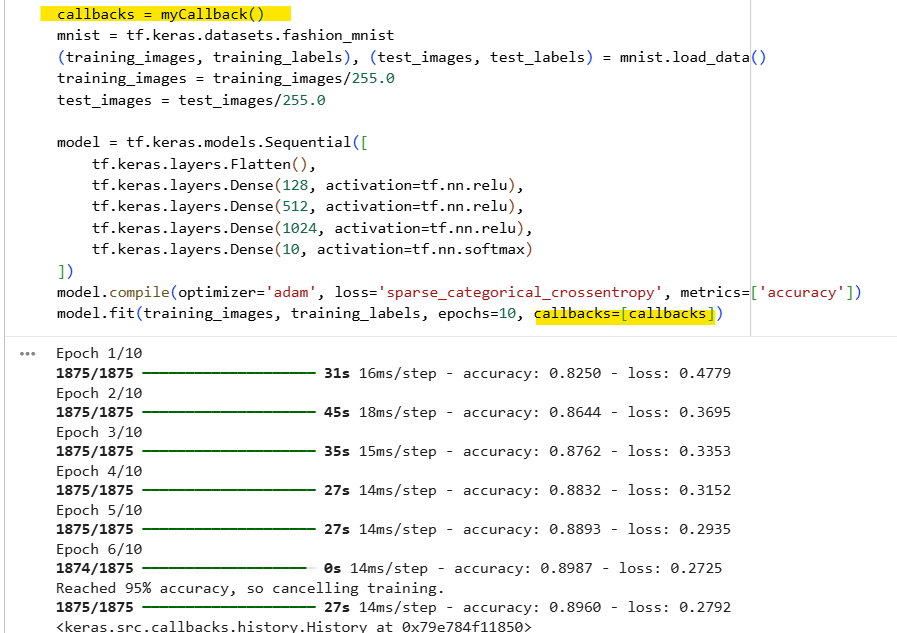

^^ With callbacks, we can see that my model stop the training at epoch 6 out 10.

In [41]:
model.evaluate(test_images, test_labels)
classifications6 = model.predict(test_images)
print(classifications6[0])
print(test_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8693 - loss: 0.3540
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[2.8299786e-07 4.6249447e-06 8.2514345e-07 6.3237927e-08 1.2682607e-07
 4.5175091e-03 2.7157887e-06 1.2915316e-02 1.7848368e-05 9.8254079e-01]
9


### Test the latest model with callbacks function

1
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.75294118 0.7372549
  0.70980392 0.74117647 0.61568627 0.64705882 0.7372549  0.69019608
  0.70196078 0.70980392 0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.05490196 0.92156863 0.83529412
  0.83529412 0.8745098  0.88235294 0.85098039 0.83921569 0.8
  0.82745098 0.74117647 0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.08627451 0.91764706 0.85098039
  0.82745098 0.85098039 0.78431373 0.79607843 0.85098039 0.79607843
  0.70196078 0.66666667 0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.

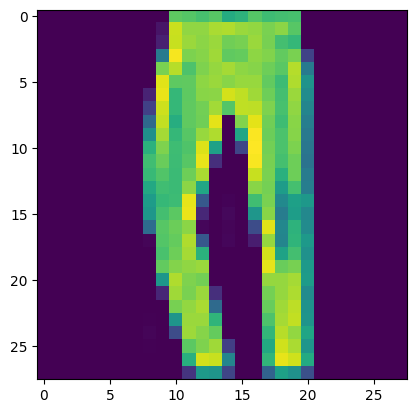

In [42]:
# Display an image
plt.imshow(test_images[5])
#Print image label at index 5
print(test_labels[5])
#Print image data at index 5
print(test_images[5])

^^ The model predicts it to be a trouser, as it prints out number 1.   
Personally, it does not look like a trouser for me, so we will test out with other pieces of clothing.

3
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.1372549  0.29803922 0.28235294
  0.         0.         0.         0.         0.31764706 0.29803922
  0.00784314 0.07058824 0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.38431373 0.81176471 0.94117647 0.71372549
  0.37647059 0.50980392 0.54117647 0.42352941 0.58823529 0.74901961
  0.75686275 0.6745098  0.30588235 0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.23137255 0.61176471 0.58823529 0.8745098  0.76078431
  0.80784314 0.52941176 0.50980392 0.25882353 0.03921569 0.35294118
  0.6        0.70196078 0.89411765 0.18039216 0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.44705882 0.631

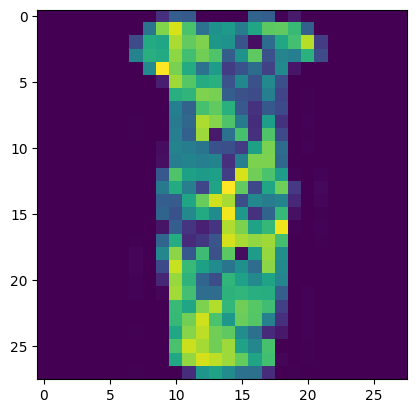

In [43]:
# Display an image
plt.imshow(test_images[100])
#Print image label at index 100
print(test_labels[100])
#Print image data at index 100
print(test_images[100])

^^ The latest model predicts test_images[100] is a dress, as it prints out number 3.

7
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.  

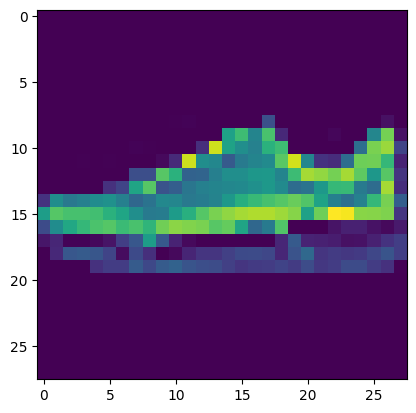

In [44]:
# Display an image
plt.imshow(test_images[9])
#Print image label at index 9
print(test_labels[9])
#Print image data at index 9
print(test_images[9])

The lastest model predicts test_images[9] is a sneaker, as it prints out number 7. The picture does look like a shoe to me.

0
[[0.         0.         0.00392157 0.         0.         0.
  0.         0.         0.32941176 0.31372549 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.05098039 0.38039216 0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.18823529 0.63137255 0.74117647 0.77254902 0.         0.
  0.         0.         0.         0.00392157 0.         0.
  0.         0.69803922 0.76470588 0.63137255 0.30980392 0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.25882353
  0.82352941 0.79215686 0.78823529 0.75686275 0.41568627 0.
  0.         0.00392157 0.00392157 0.         0.         0.
  0.5254902  0.76470588 0.70196078 0.64705882 0.86666667 0.29019608
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.01176471 0.76862745
  0.69803922 0.73333333 0.72941176 0.65098039 0.72941

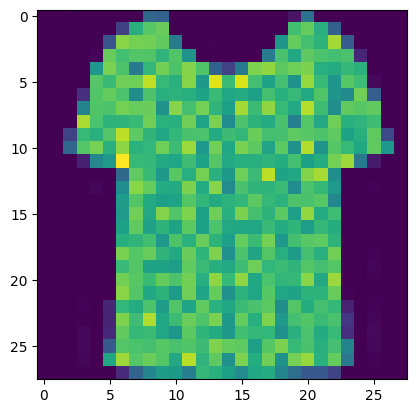

In [46]:
# Display an image
plt.imshow(test_images[1000])
#Print image label at index 1000
print(test_labels[1000])
#Print image data at index 1000
print(test_images[1000])

^^ The latest model predicts test_images[1000] is a top, as it prints out number 0. The picture indeed looks like a shirt to me.

#### For more testing, you can play around (copy and replace number in the code snippet below).

In [ ]:
### For more testing, copy and replace number in this code snippet.
# # Display an image
# plt.imshow(test_images[9])
# #Print image label at index 9
# print(test_labels[9])
# #Print image data at index 9
# print(test_images[9])